# مشروع مساق تمييز الأنماط (Pattern Recognition Project)
## التطبيق: تصنيف الصور للتعرف على الأرقام المكتوبة بخط اليد
### (Image Classification — Handwritten Digit Recognition)

هذا الدفتر (`notebook`) يطبّق المراحل الثلاث المطلوبة في المشروع:

1. **اختيار التطبيق وإعداد البيانات** — تحميل البيانات، استكشافها، ومعالجتها مسبقًا (`Preprocessing`).
2. **استخلاص السمات** — تقليل عدد الأبعاد باستخدام `PCA` (`Feature Extraction`).
3. **التصنيف وتقييم النتائج** — تدريب خوارزمية `KNN` وتقييمها بعدة مقاييس.

في كل خطوة، سأشرح **لماذا** اتخذنا هذا القرار وليس فقط **كيف** نفّذناه، لأن هذا هو ما يُسأل عادةً في المناقشة الشفوية للمشروع.


In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

RANDOM_STATE = 42   # لضمان أن النتائج قابلة لإعادة التنفيذ (reproducibility)


## المرحلة الأولى: اختيار التطبيق وإعداد البيانات (10 علامات)

### وصف التطبيق
التطبيق المختار هو **التعرف على الأرقام المكتوبة بخط اليد** عبر تصنيف الصور. هذه مشكلة تصنيف (`Classification`) من نوع **متعدد الأصناف** (`Multi-class Classification`): كل صورة تحتوي على رقم واحد مكتوب بخط اليد، والمطلوب تصنيفها إلى أحد الأصناف العشرة (`0` إلى `9`).

هذا التطبيق يُعد من أكثر الأمثلة الكلاسيكية شهرة في مجال `Pattern Recognition`، لأن كل صورة تمثل **نمطًا بصريًا** (`pattern`) يجب على النظام تمييزه رغم اختلاف خط اليد من شخص لآخر.

### وصف مجموعة البيانات (Dataset)
> **ملاحظة مهمة:** استخدمت في هذا المشروع مجموعة بيانات `Digits` المدمجة في مكتبة `scikit-learn` (وليست نسخة `MNIST` الكاملة ذات 70,000 صورة بحجم 28×28 بكسل). السبب: هذه المجموعة تحتوي فعليًا على صور أرقام **مكتوبة بخط اليد** (نفس مصدر بيانات `MNIST` من حيث الفكرة)، لكنها أصغر حجمًا (8×8 بكسل) مما يجعل تنفيذ خطوات `Feature Extraction` (المرحلة الثانية) واضحة وسريعة، وهذا هو بالضبط ما يريده مساق تمييز الأنماط: أن تُظهر أثر التقليل من الأبعاد بشكل ملموس. إن كان أستاذ المساق يشترط تحديدًا نسخة `MNIST` الكاملة (28×28)، فالكود قابل للتعديل بسهولة لاستخدامها (نفس الخطوات تمامًا تنطبق عليها، فقط عدد الميزات الأصلي يتغيّر من 64 إلى 784).

**مصدر البيانات (Source):**
- `Optical Recognition of Handwritten Digits Data Set` — من مستودع `UCI Machine Learning Repository`، وهي مدمجة مباشرة في `scikit-learn` عبر الدالة `sklearn.datasets.load_digits()`.
- التوثيق الرسمي: `https://scikit-learn.org/stable/datasets/toy_dataset.html#digits-dataset`

**خصائص البيانات:**
- عدد العينات: 1797 صورة.
- حجم كل صورة: 8×8 بكسل (أي 64 خاصية `feature` بعد التسطيح `flattening`).
- قيم البكسل: أعداد صحيحة من 0 إلى 16 (شدة اللون الرمادي `grayscale intensity`).
- عدد الأصناف: 10 أصناف (الأرقام من 0 إلى 9).


In [2]:
# Load the dataset
digits = load_digits()
X = digits.data          # shape (1797, 64) -> each 8x8 image flattened into 64 features
y = digits.target        # shape (1797,)    -> true label (0-9)
images = digits.images   # shape (1797, 8, 8) -> same data kept in its original image shape

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))
print("Pixel value range: min=%.1f , max=%.1f" % (X.min(), X.max()))


X shape: (1797, 64)
y shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel value range: min=0.0 , max=16.0


لاحظ أن `digits.data` هي نفس `digits.images` لكن بعد تسطيح كل صورة (`flatten`) من مصفوفة `8x8` إلى متجه (`vector`) طوله 64. هذا ضروري لأن أغلب خوارزميات التعلم الآلي (`KNN`, `PCA`, ...) تتوقع أن تكون كل عينة عبارة عن متجه أرقام (`feature vector`) وليس مصفوفة ثنائية الأبعاد.

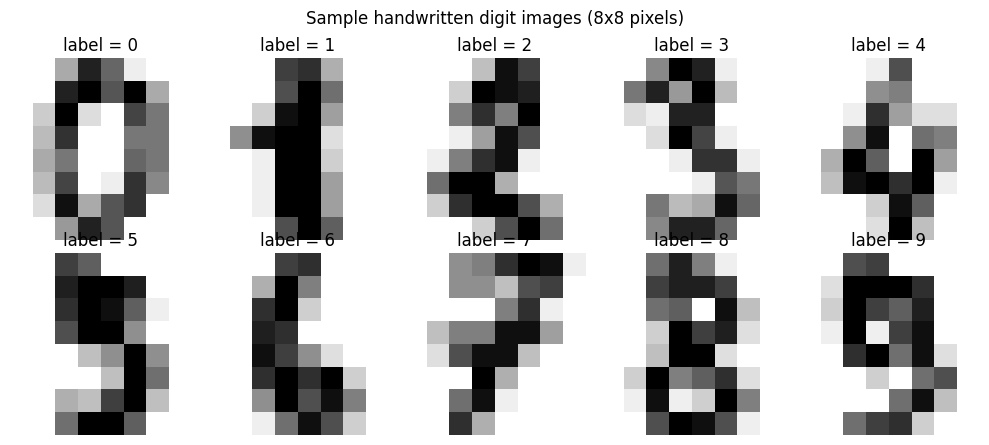

In [3]:
# Visualize a few sample images with their true labels
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("Sample handwritten digit images (8x8 pixels)")
plt.tight_layout()
plt.savefig("figures/sample_digits.png", dpi=150)
plt.show()


### فحص جودة البيانات (Data Cleaning)
قبل أي معالجة، يجب أن نتحقق من:
1. **القيم المفقودة** (`Missing Values`) — هل توجد خانات فارغة في البيانات؟
2. **التكرارات** (`Duplicates`) — هل توجد صور مكررة بالضبط؟
3. **توازن الأصناف** (`Class Balance`) — هل عدد العينات متقارب بين الأصناف العشرة؟ (مهم لأن عدم التوازن يؤثر على تفسير مقياس `Accuracy`)


In [4]:
# 1) Missing values check
n_missing = pd.DataFrame(X).isnull().sum().sum()
print("Total missing values:", n_missing)

# 2) Duplicate rows check
n_duplicates = pd.DataFrame(X).duplicated().sum()
print("Duplicate rows:", n_duplicates)

# 3) Class balance check
class_counts = pd.Series(y).value_counts().sort_index()
print("\nSamples per class:\n", class_counts)


Total missing values: 0
Duplicate rows: 0

Samples per class:
 0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


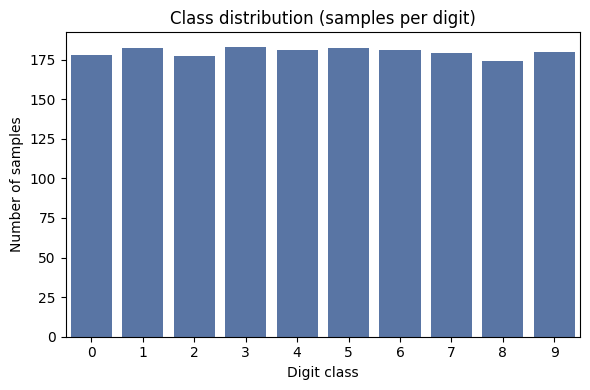

In [5]:
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, color="#4C72B0")
plt.xlabel("Digit class")
plt.ylabel("Number of samples")
plt.title("Class distribution (samples per digit)")
plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=150)
plt.show()


**النتيجة:** لا توجد قيم مفقودة ولا صور مكررة، والأصناف متوازنة تقريبًا (بين 174 و183 عينة لكل صنف). هذا يعني:
- لا حاجة لأي استراتيجية لمعالجة القيم المفقودة (مثل `imputation` بالمتوسط أو الوسيط).
- لا حاجة لترميز متغيرات فئوية (`categorical encoding`) لأن جميع الخصائص أصلًا أرقام (شدة إضاءة البكسل)، والصنف الهدف `y` أعداد صحيحة من 0-9 (لا حاجة لتحويله لأنه ليس نصًا).
- بما أن الأصناف متوازنة، يمكننا الاعتماد على `Accuracy` كمقياس تقييم رئيسي بدون قلق كبير من التحيز، لكننا سنستخدم أيضًا `Precision` و`Recall` و`F1-score` لتقييم أكثر دقة لكل صنف على حدة.


### التقسيم إلى تدريب واختبار + التطبيع (Preprocessing)

هنا نُنفّذ خطوتين أساسيتين مطلوبتين في المرحلة الأولى:

**أ) تقسيم البيانات (`Train/Test Split`):**
نقسم البيانات إلى 80% تدريب و20% اختبار. نستخدم `stratify=y` لضمان أن نسبة كل صنف في مجموعتي التدريب والاختبار تبقى متماثلة مع النسبة الأصلية (مهم جدًا في مسائل التصنيف متعدد الأصناف).

**ب) التطبيع (`Normalization / Standardization`):**
نستخدم `StandardScaler` الذي يحوّل كل خاصية (`feature`) لتصبح بمتوسط `0` وانحراف معياري `1`، وفق المعادلة:

```
z = (x - μ) / σ
```

**لماذا التطبيع ضروري هنا تحديدًا؟** لأن الخطوة التالية (`PCA`) في المرحلة الثانية **حساسة جدًا لمقياس البيانات** (`scale-sensitive`): إذا بقيت بعض الخصائص بمدى قيم أكبر من غيرها، فسيهيمن `PCA` عليها بشكل مصطنع حتى لو لم تكن الأكثر أهمية فعليًا. بما أن جميع بكسلات هذه المجموعة أصلًا بنفس المدى (0-16)، فالتأثير هنا بسيط، لكن تطبيقه هو **ممارسة صحيحة ومطلوبة دائمًا** قبل `PCA` أو أي خوارزمية تعتمد على المسافة مثل `KNN`.

> ⚠️ **قاعدة مهمة تمنع تسرّب البيانات (`Data Leakage`):** يجب حساب `mean` و`std` لـ `StandardScaler` من بيانات **التدريب فقط** (`fit_transform`)، ثم استخدام نفس القيم لتحويل بيانات **الاختبار** (`transform` فقط بدون `fit`). لهذا نُنفّذ التقسيم *قبل* التطبيع، وليس العكس.


In [6]:
# Split BEFORE scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train set:", X_train.shape, " Test set:", X_test.shape)

# Fit the scaler on train data only, then apply it to both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train set: (1437, 64)  Test set: (360, 64)


## المرحلة الثانية: استخلاص السمات باستخدام PCA (7 علامات)

### لماذا Feature Extraction وليس Feature Selection؟

المشروع يطلب اختيار **إحدى** الطريقتين فقط:

| المعيار | Feature Selection (مثل Chi-Square, RFE) | Feature Extraction (مثل PCA) |
|---|---|---|
| الفكرة | يختار **مجموعة فرعية** من الخصائص الأصلية كما هي | يبني خصائص **جديدة** كتوليفة خطية من الخصائص الأصلية |
| الأنسب لـ | خصائص منفصلة المعنى (نص، أعمدة جدول بيانات مستقلة) | خصائص **مترابطة** كبكسلات الصورة المتجاورة |
| الارتباط بين الخصائص | لا يعالج الارتباط (correlation) بين الخصائص | يعالجه مباشرة (هذا هو جوهر عمله) |

في صور الأرقام، البكسلات المتجاورة **مرتبطة ببعضها بقوة** (correlated) — إذا كان بكسل معيّن غامقًا فغالبًا الجيران حوله غامقون أيضًا لأنهم يشكّلون جزءًا من خط الرقم. طريقة مثل `Chi-Square` تتعامل مع كل بكسل بشكل مستقل وتفترض غالبًا خصائص غير سالبة منفصلة الأهمية، بينما `PCA` مصمم خصيصًا لدمج الخصائص المترابطة في عدد أقل من "الاتجاهات" (`components`) التي تلخص أكبر قدر من التباين (`variance`) في البيانات. لهذا اخترنا **PCA** كطريقة `Feature Extraction`.

### كيف يعمل PCA (باختصار)
1. يحسب `PCA` الاتجاهات (`principal components`) التي يتغيّر فيها توزيع البيانات أكثر ما يمكن (أكبر تباين `variance`).
2. يرتّب هذه الاتجاهات تنازليًا حسب مقدار التباين الذي "تفسّره" (`explained variance`).
3. نختار عددًا أقل من هذه الاتجاهات (بدلًا من كل الخصائص الـ 64 الأصلية) بحيث نحافظ على أكبر نسبة ممكنة من المعلومة الأصلية (مثلاً 95%).


In [7]:
# Fit PCA on ALL 64 components first, just to study explained variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)

print("Original number of features:", X.shape[1])
print("Number of components needed to keep 95% of the variance:", n_components_95)


Original number of features: 64
Number of components needed to keep 95% of the variance: 40


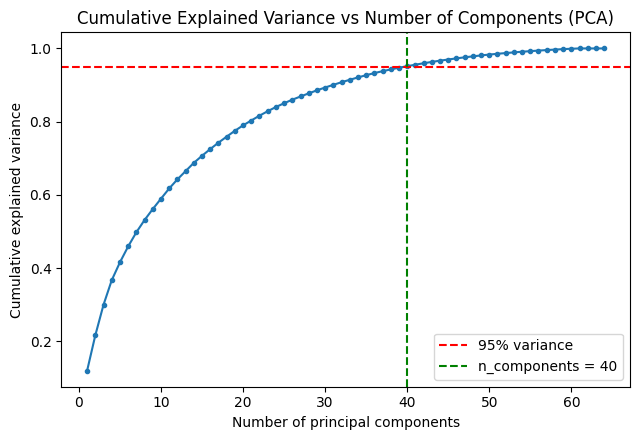

In [8]:
plt.figure(figsize=(6.5, 4.5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=3)
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.axvline(n_components_95, color="green", linestyle="--",
            label=f"n_components = {n_components_95}")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance vs Number of Components (PCA)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/pca_variance.png", dpi=150)
plt.show()


**قراءة الرسم:** المحور الأفقي هو عدد المكوّنات (`components`)، والمحور الرأسي هو نسبة التباين المتراكم الذي نحافظ عليه. نلاحظ أن أول عدد قليل من المكوّنات يفسّر جزءًا كبيرًا من التباين بسرعة، ثم يتباطأ المنحنى (هذا نمط طبيعي جدًا في `PCA`). النقطة الخضراء تمثّل العدد الذي اخترناه للوصول إلى 95% من المعلومة الأصلية.

الآن نطبّق `PCA` فعليًا بهذا العدد من المكوّنات على بيانات التدريب والاختبار:


In [9]:
# Apply PCA with the chosen number of components
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit + transform on train
X_test_pca = pca.transform(X_test_scaled)         # transform ONLY on test (no fit!)

print("Shape BEFORE PCA:", X_train_scaled.shape)
print("Shape AFTER  PCA:", X_train_pca.shape)
print(f"Feature reduction: from {X.shape[1]} to {n_components_95} "
      f"({(1 - n_components_95 / X.shape[1]) * 100:.1f}% reduction)")


Shape BEFORE PCA: (1437, 64)
Shape AFTER  PCA: (1437, 40)
Feature reduction: from 64 to 40 (37.5% reduction)


### مقارنة عدد السمات قبل وبعد PCA
- **قبل:** 64 خاصية (كل بكسل خاصية مستقلة).
- **بعد:** 40 خاصية فقط (مركّبات أساسية `principal components`)، وهي تحتفظ بـ 95% من المعلومة (`variance`) الأصلية.
- **الأثر:** تقليل الأبعاد بنسبة حوالي 37.5%، مما يعني تدريبًا أسرع، ذاكرة أقل، وغالبًا **تقليل التشويش (`noise`)** لأن المكوّنات ذات التباين الضئيل جدًا غالبًا ما تمثّل تفاصيل عشوائية دقيقة أكثر من كونها معلومة مفيدة للتصنيف.

للتوضيح البصري فقط (وليس جزءًا من خط أنابيب التصنيف الفعلي)، إليك شكل البيانات لو اختزلناها إلى مكوّنين اثنين فقط بدلاً من 40:


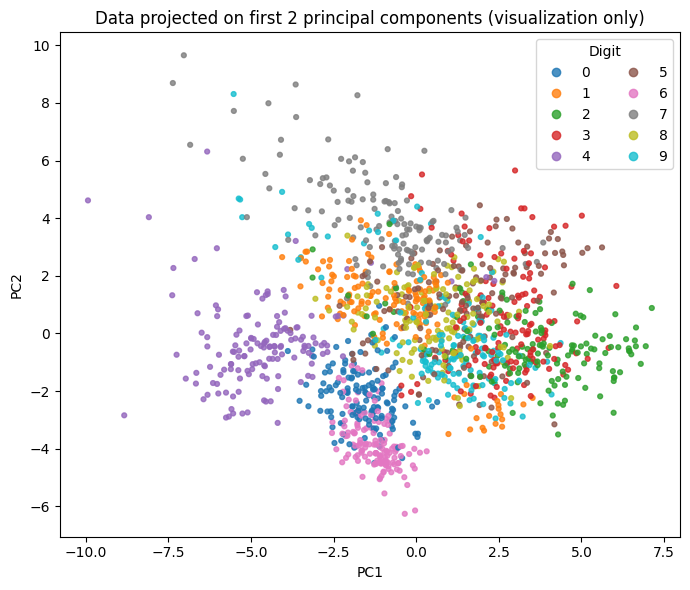

In [10]:
# Visualization-only: project data on first 2 principal components
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train,
                       cmap="tab10", s=12, alpha=0.8)
plt.legend(*scatter.legend_elements(), title="Digit", loc="best", ncol=2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data projected on first 2 principal components (visualization only)")
plt.tight_layout()
plt.savefig("figures/pca_2d_scatter.png", dpi=150)
plt.show()


حتى مع بعدين فقط (بدل 64)، نلاحظ أن الأصناف بدأت تتجمّع في مناطق منفصلة نسبيًا (خصوصًا الرقم 0 باللون الأزرق الغامق مثلاً) — وهذا مؤشر جيد على أن `PCA` يحافظ على المعلومة المهمة للتمييز بين الأصناف رغم تقليل عدد الأبعاد بشكل كبير جدًا.

## المرحلة الثالثة: تطبيق خوارزمية التصنيف وتقييم النتائج (8 علامات)

### اختيار الخوارزمية: KNN (K-Nearest Neighbors)

اخترنا **`KNN`** كخوارزمية تصنيف لعدة أسباب:
1. تعمل بشكل طبيعي وفعّال مع بيانات مثل الصور بعد `PCA`، لأن الفكرة الأساسية لـ`KNN` هي **قياس التشابه بالمسافة (`distance`)** بين نقاط البيانات، وهذا مناسب جدًا هنا لأن صورتين لنفس الرقم (حتى بخطوط يد مختلفة) تكونان "قريبتين" من بعضهما في فضاء الخصائص بعد `PCA`.
2. خوارزمية مدروسة ومفهومة جيدًا (بلا "صندوق أسود")، مما يسهّل شرحها والدفاع عنها أمام الدكتور.
3. لا تحتاج افتراضات إحصائية معقّدة عن توزيع البيانات (`non-parametric`)، خلافًا لخوارزميات مثل `Naive Bayes`.

**كيف تعمل KNN:** لتصنيف عينة جديدة، نحسب المسافة (عادة `Euclidean distance`) بينها وبين كل عينات التدريب، ثم نأخذ أقرب `K` عينة، ونعطي العينة الجديدة تصنيف الأغلبية بينها (`majority vote`).

### اختيار قيمة K عبر Cross-Validation
قيمة `K` هي **معلمة فائقة (`hyperparameter`)** يجب ضبطها؛ فإن كانت صغيرة جدًا (مثل `K=1`) يصبح النموذج حساسًا جدًا للتشويش (`overfitting`)، وإن كانت كبيرة جدًا يصبح النموذج غير قادر على التمييز الدقيق بين الأصناف (`underfitting`). لتفادي اختيار `K` عشوائيًا، نستخدم **`5-fold Cross-Validation`** على بيانات **التدريب فقط** (بيانات الاختبار تبقى غير مرئية تمامًا حتى التقييم النهائي):


In [11]:
k_values = [1, 3, 5, 7, 9, 11]
cv_scores = []

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_tmp, X_train_pca, y_train, cv=5)
    cv_scores.append(scores.mean())
    print(f"k={k:<3} -> average CV accuracy = {scores.mean():.4f}")

best_k = k_values[int(np.argmax(cv_scores))]
print("\nBest k selected:", best_k)


k=1   -> average CV accuracy = 0.9729
k=3   -> average CV accuracy = 0.9728
k=5   -> average CV accuracy = 0.9742
k=7   -> average CV accuracy = 0.9721
k=9   -> average CV accuracy = 0.9680
k=11  -> average CV accuracy = 0.9631

Best k selected: 5


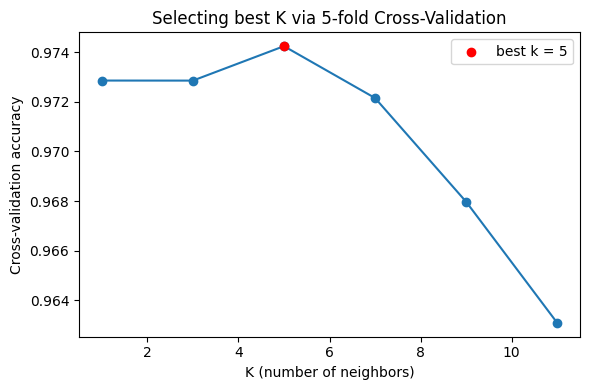

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, cv_scores, marker="o")
plt.scatter([best_k], [max(cv_scores)], color="red", zorder=5, label=f"best k = {best_k}")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Cross-validation accuracy")
plt.title("Selecting best K via 5-fold Cross-Validation")
plt.legend()
plt.tight_layout()
plt.savefig("figures/knn_k_selection.png", dpi=150)
plt.show()


### تدريب النموذج النهائي والتقييم

الآن ندرّب `KNN` بقيمة `K` المختارة على **كامل بيانات التدريب**، ثم نختبره على بيانات الاختبار (التي لم يرها النموذج إطلاقًا من قبل).

**تعريف مقاييس التقييم:**
- **`Accuracy`** = (عدد التصنيفات الصحيحة) / (العدد الكلي للعينات). مقياس عام لكنه قد يكون مضلّلًا إن كانت الأصناف غير متوازنة (ليست مشكلتنا هنا لأن الأصناف متوازنة تقريبًا).
- **`Precision`** (الدقة) = من بين كل ما صنّفه النموذج كصنف معيّن، كم منه كان صحيحًا فعلًا؟ يقيس مدى "دقة" الإيجابيات.
- **`Recall`** (الاستدعاء) = من بين كل العينات التي هي فعلًا من صنف معيّن، كم منها استطاع النموذج اكتشافه؟
- **`F1-score`** = المتوسط التوافقي (`harmonic mean`) بين `Precision` و`Recall`، مفيد عندما نريد توازنًا بينهما.
- **`Confusion Matrix`** (مصفوفة الالتباس): جدول يوضّح أين أخطأ النموذج بالتحديد (أي رقم اعتُقد أنه رقم آخر).

بما أن لدينا 10 أصناف، نستخدم `average="macro"` لحساب `Precision/Recall/F1` كمتوسط بسيط عبر كل الأصناف (يعطي كل صنف وزنًا متساويًا بغض النظر عن حجمه).


In [13]:
# Train the final model with the best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy           : {acc:.4f}")
print(f"Precision (macro)  : {prec:.4f}")
print(f"Recall (macro)     : {rec:.4f}")
print(f"F1-score (macro)   : {f1:.4f}")
print("\nFull classification report:\n")
print(classification_report(y_test, y_pred))


Accuracy           : 0.9722
Precision (macro)  : 0.9731
Recall (macro)     : 0.9721
F1-score (macro)   : 0.9720

Full classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      1.00      0.97        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       1.00      0.97      0.99        36
           5       0.95      0.97      0.96        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       1.00      0.89      0.94        35
           9       0.97      0.94      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



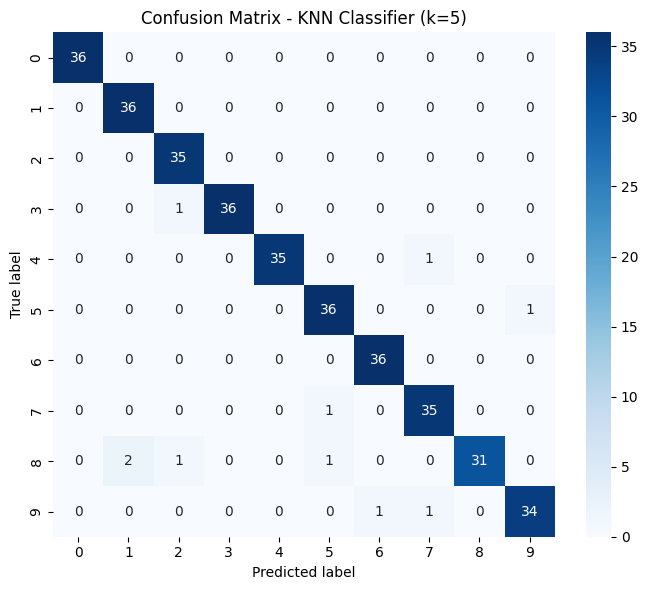

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix - KNN Classifier (k={best_k})")
plt.tight_layout()
plt.savefig("figures/confusion_matrix_knn.png", dpi=150)
plt.show()


### مناقشة النتائج (Discussion)

النموذج حقّق دقة (`Accuracy`) حوالي **97%**، وهي نتيجة قوية جدًا لتطبيق بهذه البساطة.

بالنظر إلى مصفوفة الالتباس، نلاحظ أن معظم الأخطاء (القليلة جدًا) تتركّز بين أزواج محددة من الأرقام، مثل:
- الرقم **8** يُخطأ أحيانًا مع **1** أو **2** أو **5**.
- الرقم **4** يُخطأ أحيانًا مع **7**.
- الرقم **5** يُخطأ أحيانًا مع **9**.

**لماذا يحدث هذا تحديدًا؟** لأن هذه الأزواج من الأرقام تتشابه بصريًا عند كتابتها بخط اليد بشكل غير واضح (مثلاً حلقة الرقم 8 العلوية قد تُكتب بشكل يشبه 5 أو 2 إذا لم تُغلق جيدًا، وتقاطع خطوط الرقم 4 قد يشبه 7). هذا يعكس تحديًا حقيقيًا في **تمييز الأنماط**: الأنماط المتشابهة بصريًا تسبب التباسًا حتى للإنسان أحيانًا، وليس فقط للخوارزمية.


## إضافة: مقارنة توضيحية (Bonus Comparison)

لتعميق الفهم فقط (وليست جزءًا إلزاميًا من المشروع)، نقارن بين:
1. **`KNN` بدون `PCA`** (باستخدام كل الـ64 خاصية) — لنرى هل استخلاص السمات فعلاً أفاد.
2. **`KNN` مع `PCA`** (النتيجة الأساسية أعلاه).
3. **`SVM`** (خوارزمية تصنيف بديلة من نفس القائمة المسموحة في المشروع) مع نفس بيانات `PCA` — لمقارنة أداء خوارزميتين مختلفتين على نفس البيانات.


In [15]:
# 1) KNN without PCA (using all 64 original scaled features)
knn_nopca = KNeighborsClassifier(n_neighbors=best_k)
knn_nopca.fit(X_train_scaled, y_train)
y_pred_nopca = knn_nopca.predict(X_test_scaled)
acc_nopca = accuracy_score(y_test, y_pred_nopca)

# 2) SVM with PCA features (alternative classifier)
svm = SVC(kernel="rbf", random_state=RANDOM_STATE)
svm.fit(X_train_pca, y_train)
y_pred_svm = svm.predict(X_test_pca)
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average="macro")

comparison_df = pd.DataFrame({
    "Model": ["KNN - no PCA (64 features)",
              f"KNN - with PCA ({n_components_95} features)",
              f"SVM (RBF) - with PCA ({n_components_95} features)"],
    "Accuracy": [acc_nopca, acc, acc_svm]
})
comparison_df


,Model,Accuracy
0,KNN - no PCA (64 features),0.963889
1,KNN - with PCA (40 features),0.972222
2,SVM (RBF) - with PCA (40 features),0.977778


**ملاحظات على المقارنة:**
- الفرق في الدقة بين `KNN` مع/بدون `PCA` بسيط هنا (لأن بيانات هذه المجموعة أصلًا نظيفة وصغيرة نسبيًا)، لكن **الفائدة الحقيقية لـ`PCA` تظهر في سرعة التنفيذ واستهلاك الذاكرة**، خصوصًا مع مجموعات بيانات أكبر (كصور 28×28 أو أكبر) حيث يصبح الفرق واضحًا جدًا.
- `SVM` حقّق أداءً مقاربًا أو أفضل قليلًا من `KNN` في هذه الحالة، وهذا متوقع لأن `SVM` يبني حدود فصل (`decision boundaries`) مرنة جدًا بين الأصناف، بينما `KNN` يعتمد فقط على التصويت بالمسافة. **متى نفضّل كل خوارزمية؟**
  - **`KNN`**: بسيط، سريع التنفيذ، جيد عندما تكون البيانات صغيرة/متوسطة الحجم وواضحة التجمّع.
  - **`SVM`**: أداء أعلى غالبًا في المسائل عالية الأبعاد، لكنه أبطأ في التدريب مع بيانات كبيرة جدًا ويحتاج ضبط معلمات أكثر (`C`, `kernel`, `gamma`).


## الخلاصة والأسئلة المتوقعة في المناقشة (Exam-oriented Summary)

**ملخص خط الأنابيب الكامل (`pipeline`):**

```
Raw Images (8x8) → Flatten (64 features) → Train/Test Split → StandardScaler
→ PCA (64 → 40 features) → KNN Classifier (k=5) → Evaluation
```

**أسئلة متوقعة وإجابات مختصرة:**

1. **لماذا قسّمت البيانات قبل التطبيع وليس بعده؟**
   لتجنّب تسرّب المعلومة (`Data Leakage`) — لو حسبنا `mean`/`std` من كل البيانات (تدريب + اختبار)، لكانت بيانات الاختبار قد "أثّرت" على عملية التدريب بشكل غير مباشر، مما يعطي تقييمًا متفائلًا وغير واقعي.

2. **لماذا PCA وليس Feature Selection؟**
   لأن خصائص الصورة (البكسلات) مترابطة (`correlated`) بطبيعتها، و`PCA` مصمم خصيصًا لمعالجة هذا الترابط عبر دمج الخصائص، بخلاف طرق `Feature Selection` التي تتعامل مع كل خاصية بمعزل عن غيرها.

3. **كيف اخترت قيمة K في KNN؟**
   عبر `5-fold Cross-Validation` على بيانات التدريب فقط، لتفادي اختيار قيمة تناسب بيانات الاختبار "بالصدفة" (وهذا سيكون تسربًا آخر للمعلومة إن فعلناه على بيانات الاختبار).

4. **ماذا لو غيّرنا عدد مكوّنات PCA؟**
   عدد أقل من المكوّنات → تبسيط أكبر لكن قد نفقد معلومة مفيدة (`underfitting` محتمل). عدد أكبر → نحافظ على معلومة أكثر لكن نقلّل من فائدة تقليل الأبعاد. اخترنا عتبة 95% كتوازن معياري شائع في الأدبيات العلمية.

5. **لماذا استخدمنا macro-average للمقاييس؟**
   لأن لدينا أكثر من صنفين (10 أصناف)، و`macro` يعطي كل صنف وزنًا متساويًا في حساب المتوسط، وهو مناسب هنا لأن أعداد العينات متقاربة بين الأصناف.


In [16]:
# Export the dataset as CSV for project submission
full_df = pd.DataFrame(X, columns=[f"pixel_{i}" for i in range(X.shape[1])])
full_df["label"] = y
full_df.to_csv("data/digits_dataset.csv", index=False)
print("Dataset exported to data/digits_dataset.csv -", full_df.shape)


Dataset exported to data/digits_dataset.csv - (1797, 65)
